# Multi-Phase Flow Rate Prediction using Volve Field dataset

### Targets: BORE_OIL_VOL · BORE_GAS_VOL · BORE_WAT_VOL

Design by  
**Charles James (S25008733)**  
MSc. Computer Science department  

---
**Run all cells top to bottom. Upload `Volve_production_data.xlsx` to your Google Drive first.**

## Setup — Install Dependencies and Mount Drive

In [1]:
# Install required packages
!pip install xgboost shap openpyxl scikit-learn -q

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/Volve_production_data.xlsx'
print("Data path:", DATA_PATH)

Mounted at /content/drive
Data path: /content/drive/MyDrive/Volve_production_data.xlsx


In [3]:
# Core imports
import pandas as pd
import numpy as np
import warnings
import copy
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor)
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import xgboost as xgb
import shap

plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
print("All imports successful.")

All imports successful.


## Section 1: Data Loading & Exploration


In [4]:
# Section 1: Data Loading & Exploration
df_daily   = pd.read_excel(DATA_PATH, sheet_name='Daily Production Data')
df_monthly = pd.read_excel(DATA_PATH, sheet_name='Monthly Production Data')

print(f"Daily sheet shape   : {df_daily.shape}")
print(f"Monthly sheet shape : {df_monthly.shape}")
print(f"Date range          : {df_daily['DATEPRD'].min().date()} → {df_daily['DATEPRD'].max().date()}")

print(f"\nFLOW_KIND distribution:")
print(df_daily['FLOW_KIND'].value_counts().to_string())

print(f"\nWells and record counts:")
for w in sorted(df_daily['WELL_BORE_CODE'].unique()):
    n = (df_daily['WELL_BORE_CODE'] == w).sum()
    print(f"  {w:<30s} {n:5d} records")

print(f"\nMissing values (% of total rows):")
miss = (df_daily.isnull().sum() / len(df_daily) * 100).round(1)
print(miss[miss > 0].to_string())

Daily sheet shape   : (15634, 24)
Monthly sheet shape : (527, 10)
Date range          : 2007-09-01 → 2016-12-01

FLOW_KIND distribution:
FLOW_KIND
production    9161
injection     6473

Wells and record counts:
  NO 15/9-F-1 C                    746 records
  NO 15/9-F-11 H                  1165 records
  NO 15/9-F-12 H                  3056 records
  NO 15/9-F-14 H                  3056 records
  NO 15/9-F-15 D                   978 records
  NO 15/9-F-4 AH                  3327 records
  NO 15/9-F-5 AH                  3306 records

Missing values (% of total rows):
ON_STREAM_HRS                1.8
AVG_DOWNHOLE_PRESSURE       42.6
AVG_DOWNHOLE_TEMPERATURE    42.6
AVG_DP_TUBING               42.6
AVG_ANNULUS_PRESS           49.5
AVG_CHOKE_SIZE_P            43.0
AVG_CHOKE_UOM               41.4
AVG_WHP_P                   41.4
AVG_WHT_P                   41.5
DP_CHOKE_SIZE                1.9
BORE_OIL_VOL                41.4
BORE_GAS_VOL                41.4
BORE_WAT_VOL                4

## Section 2: Handling Missing Values


After injection removal  : 9,161 rows
After oil>0 and hrs>0    : 8,007 rows
Negative water records   : 4 clipped to 0

Remaining missingness after filter:
AVG_DOWNHOLE_PRESSURE        1.8
AVG_DOWNHOLE_TEMPERATURE     1.8
AVG_DP_TUBING                1.8
AVG_ANNULUS_PRESS           11.8


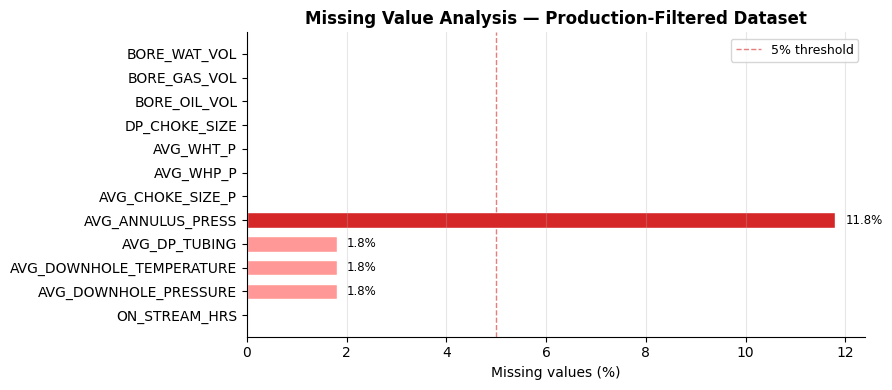

In [5]:
# Section 2: Handling Missing Values
FEATURES_BASE = [
    'ON_STREAM_HRS',             # Hours the well actively flowed
    'AVG_DOWNHOLE_PRESSURE',     # Reservoir drive pressure (bar)
    'AVG_DOWNHOLE_TEMPERATURE',  # Fluid viscosity proxy (degC)
    'AVG_DP_TUBING',             # Pressure drop across production tubing
    'AVG_ANNULUS_PRESS',         # Annulus pressure — gas migration indicator
    'AVG_CHOKE_SIZE_P',          # Choke opening percentage (primary flow control)
    'AVG_WHP_P',                 # Wellhead pressure (bar)
    'AVG_WHT_P',                 # Wellhead temperature (degC)
    'DP_CHOKE_SIZE',             # Physical choke diameter (mm)
]
TARGETS = ['BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL']

# Step 1 — Remove injection records
# Injection wells (F-4 AH, F-5 AH) operate under pump-head pressure, not
# reservoir drive. Including them would teach the model a false
# pressure-to-flowrate relationship that inverts production physics.
df_prod = df_daily[df_daily['FLOW_KIND'] == 'production'].copy()
print(f"After injection removal  : {len(df_prod):,} rows")

# Step 2 — Remove zero-oil and zero-hours rows
# Zero-oil rows are shut-in periods or artefacts; zero-hours rows have no
# active flow. Both carry no multi-phase flow physics information and would
# bias regression toward zero predictions.
df_prod = df_prod[
    (df_prod['BORE_OIL_VOL'] > 0) &
    (df_prod['ON_STREAM_HRS'] > 0)
].copy().sort_values('DATEPRD').reset_index(drop=True)
print(f"After oil>0 and hrs>0    : {len(df_prod):,} rows")

# Step 3 — Clip negative water volume
# Four records show BORE_WAT_VOL < 0 (min: -457.8 Sm³) — a measurement
# artefact. Negative volume is physically impossible. Clip to 0 rather than
# drop, preserving the associated oil and gas sensor readings.
# Without this clip, log1p(negative) returns NaN and corrupts the target array.
neg_water = (df_prod['BORE_WAT_VOL'] < 0).sum()
df_prod['BORE_WAT_VOL'] = df_prod['BORE_WAT_VOL'].clip(lower=0)
print(f"Negative water records   : {neg_water} clipped to 0")

print(f"\nRemaining missingness after filter:")
miss2 = (df_prod[FEATURES_BASE + TARGETS].isnull().sum() / len(df_prod) * 100).round(1)
print(miss2[miss2 > 0].to_string())

# Visualise missing values
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#d62728' if v > 5 else '#ff9896' if v > 0 else '#c7e9c0'
          for v in miss2.values]
bars = ax.barh(miss2.index, miss2.values, color=colors, edgecolor='white', height=0.65)
ax.axvline(5, color='#d62728', lw=1, ls='--', alpha=0.6, label='5% threshold')
for v, b in zip(miss2.values, bars):
    if v > 0:
        ax.text(v + 0.2, b.get_y() + b.get_height()/2,
                f'{v:.1f}%', va='center', fontsize=8.5)
ax.set_xlabel('Missing values (%)')
ax.set_title('Missing Value Analysis — Production-Filtered Dataset', fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

## Section 3: Data Type Conversion

In [6]:
# Section 3: Data Type Conversion
df_prod['DATEPRD'] = pd.to_datetime(df_prod['DATEPRD'])

for col in FEATURES_BASE + TARGETS:
    df_prod[col] = pd.to_numeric(df_prod[col], errors='coerce')

print("Column dtypes after conversion:")
print(f"  DATEPRD          : {df_prod['DATEPRD'].dtype}")
print(f"  Sensor columns   : {df_prod[FEATURES_BASE[0]].dtype}")
print(f"  Target columns   : {df_prod[TARGETS[0]].dtype}")
print(f"  WELL_BORE_CODE   : {df_prod['WELL_BORE_CODE'].dtype}  (string → one-hot in Section 5)")

Column dtypes after conversion:
  DATEPRD          : datetime64[ns]
  Sensor columns   : float64
  Target columns   : float64
  WELL_BORE_CODE   : object  (string → one-hot in Section 5)


## Section 4: Feature Engineering

In [7]:
# Section 4: Feature Engineering
df_prod['CUM_DAYS'] = df_prod.groupby('WELL_BORE_CODE').cumcount()

for col in TARGETS:
    # Intervention 1: rolling means across 6 time windows (all lag-safe)
    for w in [3, 7, 14, 30, 60, 90]:
        df_prod[f'{col}_roll{w}'] = df_prod.groupby('WELL_BORE_CODE')[col].transform(
            lambda x, ww=w: x.shift(1).rolling(ww, min_periods=max(1, ww // 5)).mean()
        )
    # Lag features: yesterday and 7 days ago
    df_prod[f'{col}_lag1'] = df_prod.groupby('WELL_BORE_CODE')[col].transform(
        lambda x: x.shift(1))
    df_prod[f'{col}_lag7'] = df_prod.groupby('WELL_BORE_CODE')[col].transform(
        lambda x: x.shift(7))
    # Decline ratio: recent 14-day mean vs 90-day baseline
    # Value < 1.0 = well is declining; > 1.0 = recovering
    df_prod[f'{col}_decline'] = (
        (df_prod[f'{col}_roll14'] + 1) /
        (df_prod[f'{col}_roll90'] + 1)
    ).clip(0.01, 10.0)
    # Intervention 4: cumulative production (reservoir energy depletion proxy)
    df_prod[f'CUM_{col}'] = (
        df_prod.groupby('WELL_BORE_CODE')[col].cumsum().shift(1).fillna(0)
    )

FEAT_ROLL = [f'{t}_roll{w}' for t in TARGETS for w in [3, 7, 14, 30, 60, 90]]
FEAT_LAG  = [f'{t}_lag1' for t in TARGETS] + [f'{t}_lag7' for t in TARGETS]
FEAT_DEC  = [f'{t}_decline' for t in TARGETS]
FEAT_CUM  = [f'CUM_{t}' for t in TARGETS]

print("Engineered feature summary:")
print(f"  Base sensor features    : {len(FEATURES_BASE)}")
print(f"  CUM_DAYS                : 1")
print(f"  Rolling means (6w × 3t) : {len(FEAT_ROLL)}")
print(f"  Lag features (2l × 3t)  : {len(FEAT_LAG)}")
print(f"  Decline ratios (3t)     : {len(FEAT_DEC)}")
print(f"  Cumulative prod (3t)    : {len(FEAT_CUM)}")

Engineered feature summary:
  Base sensor features    : 9
  CUM_DAYS                : 1
  Rolling means (6w × 3t) : 18
  Lag features (2l × 3t)  : 6
  Decline ratios (3t)     : 3
  Cumulative prod (3t)    : 3


## Section 5: Encoding Categorical Variables

Well dummy columns added: ['WELL_NO 15/9-F-1 C', 'WELL_NO 15/9-F-11 H', 'WELL_NO 15/9-F-12 H', 'WELL_NO 15/9-F-14 H', 'WELL_NO 15/9-F-15 D', 'WELL_NO 15/9-F-5 AH']
Total features           : 46
  9 sensor + 1 CUM_DAYS + 18 rolling + 6 lag + 3 decline + 3 CUM + 6 well dummies


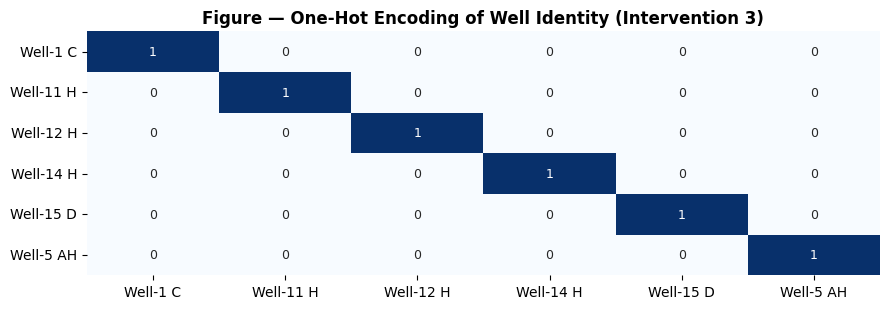

In [8]:
# Section 5: Encoding Categorical Variables
well_dummies = pd.get_dummies(df_prod['WELL_BORE_CODE'], prefix='WELL', dtype=float)
WELL_COLS = list(well_dummies.columns)
df_prod = pd.concat([df_prod, well_dummies], axis=1)

FEATURES_ALL = (FEATURES_BASE + ['CUM_DAYS'] + FEAT_ROLL +
                FEAT_LAG + FEAT_DEC + FEAT_CUM + WELL_COLS)

print(f"Well dummy columns added: {WELL_COLS}")
print(f"Total features           : {len(FEATURES_ALL)}")
print(f"  9 sensor + 1 CUM_DAYS + 18 rolling + 6 lag + 3 decline + 3 CUM + {len(WELL_COLS)} well dummies")

# Visualise one-hot encoding structure
fig, ax = plt.subplots(figsize=(9, 3.2))
mat = np.eye(len(WELL_COLS))
sns.heatmap(mat, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=[w.replace('WELL_NO 15/9-F-', 'Well-') for w in WELL_COLS],
            yticklabels=[w.replace('WELL_NO 15/9-F-', 'Well-') for w in WELL_COLS],
            cbar=False, ax=ax, annot_kws={'size': 9})
ax.set_title('Figure — One-Hot Encoding of Well Identity (Intervention 3)',
             fontweight='bold')
plt.tight_layout(); plt.show()

## Section 6: Feature Scaling


In [9]:
# Section 6: Feature Scaling
df_clean = (df_prod[FEATURES_ALL + TARGETS + ['DATEPRD', 'WELL_BORE_CODE']]
            .dropna().reset_index(drop=True))
n = len(df_clean)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)
train = df_clean.iloc[:n_train].copy().reset_index(drop=True)
val   = df_clean.iloc[n_train : n_train + n_val].copy().reset_index(drop=True)
test  = df_clean.iloc[n_train + n_val :].copy().reset_index(drop=True)

print(f"Clean dataset   : {n:,} rows  |  {len(FEATURES_ALL)} features")
print(f"Train (70%)     : {len(train):,}  "
      f"({train['DATEPRD'].min().date()} → {train['DATEPRD'].max().date()})")
print(f"Validation (15%): {len(val):,}   "
      f"({val['DATEPRD'].min().date()} → {val['DATEPRD'].max().date()})")
print(f"Test (15%)      : {len(test):,}   "
      f"({test['DATEPRD'].min().date()} → {test['DATEPRD'].max().date()})")

# Log1p transform targets (applied to all splits)
LOG_COLS = ['log_OIL', 'log_GAS', 'log_WAT']
for split in [train, val, test]:
    split['log_OIL'] = np.log1p(split['BORE_OIL_VOL'].values)
    split['log_GAS'] = np.log1p(split['BORE_GAS_VOL'].values)
    split['log_WAT'] = np.log1p(split['BORE_WAT_VOL'].values)

print("\nLog1p skewness reduction:")
for lc, rc in zip(LOG_COLS, TARGETS):
    sk_r = train[rc].skew(); sk_l = train[lc].skew()
    tr_ratio = train[rc].mean() / test[rc].mean()
    log_ratio = train[lc].mean() / test[lc].mean()
    print(f"  {rc}: skew {sk_r:.2f} → {sk_l:.2f}  |  "
          f"scale ratio raw={tr_ratio:.2f}  log={log_ratio:.2f}")

# Feature arrays
X_train = train[FEATURES_ALL].values.astype(float)
X_val   = val[FEATURES_ALL].values.astype(float)
X_test  = test[FEATURES_ALL].values.astype(float)
y_train = train[LOG_COLS].values.astype(float)
y_val   = val[LOG_COLS].values.astype(float)
y_test_raw = test[TARGETS].values.astype(float)

# MinMaxScaler — fit ONLY on training data
scaler    = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)   # fit + transform
X_val_s   = scaler.transform(X_val)          # transform only
X_test_s  = scaler.transform(X_test)         # transform only
print(f"\nScaler fitted on training data only.")
print(f"Feature range after scaling: [{X_train_s.min():.3f}, {X_train_s.max():.3f}]")

Clean dataset   : 6,863 rows  |  46 features
Train (70%)     : 4,804  (2008-03-01 → 2015-02-11)
Validation (15%): 1,029   (2015-02-11 → 2015-11-08)
Test (15%)      : 1,030   (2015-11-08 → 2016-09-17)

Log1p skewness reduction:
  BORE_OIL_VOL: skew 1.43 → -0.53  |  scale ratio raw=4.15  log=1.23
  BORE_GAS_VOL: skew 1.37 → -0.62  |  scale ratio raw=3.88  log=1.12
  BORE_WAT_VOL: skew -0.16 → -1.35  |  scale ratio raw=1.33  log=0.91

Scaler fitted on training data only.
Feature range after scaling: [0.000, 1.000]


## Section 7: Outlier Detection


Outlier analysis — IQR × 3.0 fence:

  BORE_OIL_VOL: fence [-3138, 4776]  →  254 outliers (3.7%)  → RETAINED
  BORE_GAS_VOL: fence [-475002, 722387]  →  160 outliers (2.3%)  → RETAINED
  BORE_WAT_VOL: fence [-9737, 13516]  →  0 outliers (0.0%)  → RETAINED


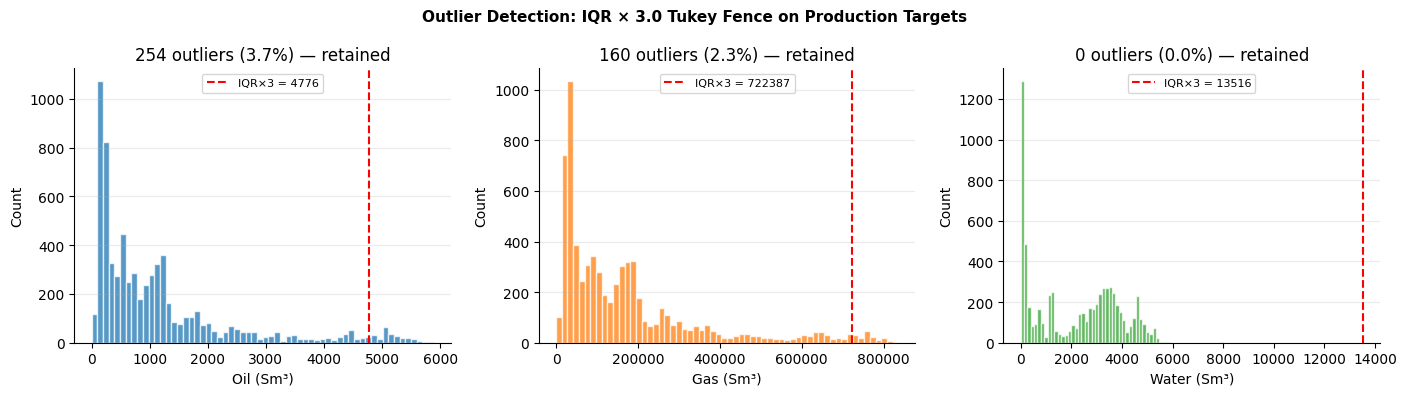

In [10]:
# Section 7: Outlier Detection
print("Outlier analysis — IQR × 3.0 fence:\n")
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, c, lab in zip(axes, TARGETS,
                            ['#1f77b4', '#ff7f0e', '#2ca02c'],
                            ['Oil (Sm³)', 'Gas (Sm³)', 'Water (Sm³)']):
    data = df_clean[col].clip(lower=0)
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
    n_out = int(((data < lo) | (data > hi)).sum())
    pct   = n_out / len(data) * 100
    print(f"  {col}: fence [{lo:.0f}, {hi:.0f}]  →  {n_out} outliers ({pct:.1f}%)  → RETAINED")
    ax.hist(data, bins=60, color=c, alpha=0.75, edgecolor='white', lw=0.2)
    ax.axvline(hi, color='red', lw=1.5, ls='--', label=f'IQR×3 = {hi:.0f}')
    ax.set_xlabel(lab); ax.set_ylabel('Count')
    ax.set_title(f'{n_out} outliers ({pct:.1f}%) — retained')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.25)
fig.suptitle('Outlier Detection: IQR × 3.0 Tukey Fence on Production Targets',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

## Section 8: Final Dataset Preparation

Summary of the complete pipeline output before modelling.

In [11]:
# Section 8: Final Dataset Summary
print("=" * 55)
print("FINAL DATASET READY FOR MODELLING")
print("=" * 55)
print(f"Total clean records       : {n:,}")
print(f"Features (X)              : {len(FEATURES_ALL)}")
print(f"  Raw sensor              : 9")
print(f"  CUM_DAYS                : 1")
print(f"  Rolling means           : 18  (6 windows × 3 targets)")
print(f"  Lag features            : 6   (lag1, lag7 × 3 targets)")
print(f"  Decline ratios          : 3")
print(f"  Cumulative production   : 3")
print(f"  Well one-hot dummies    : {len(WELL_COLS)}")
print(f"Targets (y, log-space)    : {LOG_COLS}")
print(f"X_train_s shape           : {X_train_s.shape}")
print(f"X_val_s   shape           : {X_val_s.shape}")
print(f"X_test_s  shape           : {X_test_s.shape}")
print(f"y_train   shape           : {y_train.shape}")

FINAL DATASET READY FOR MODELLING
Total clean records       : 6,863
Features (X)              : 46
  Raw sensor              : 9
  CUM_DAYS                : 1
  Rolling means           : 18  (6 windows × 3 targets)
  Lag features            : 6   (lag1, lag7 × 3 targets)
  Decline ratios          : 3
  Cumulative production   : 3
  Well one-hot dummies    : 6
Targets (y, log-space)    : ['log_OIL', 'log_GAS', 'log_WAT']
X_train_s shape           : (4804, 46)
X_val_s   shape           : (1029, 46)
X_test_s  shape           : (1030, 46)
y_train   shape           : (4804, 3)


## Section 9: Model Implementation & Evaluation

### Evaluation Helper
All models are evaluated using three metrics computed in original Sm³ space
after back-transforming log-space predictions with `expm1()`:
- **R²** proportion of production variance explained (1.0 = perfect)
- **MAE** average absolute error in Sm³/day (lower = better)
- **RMSE** root mean squared error in Sm³/day; penalises large errors more than MAE

In [12]:
# Evaluation helper — R², MAE, RMSE
def evaluate(model, label):
    """
    Train model, predict on test set, compute R², MAE, RMSE.
    Predictions are back-transformed from log space via expm1().
    Returns a results dict and stores predictions in results['pred'].
    """
    m = copy.deepcopy(model)
    m.fit(X_train_s, y_train)

    ptr      = m.predict(X_train_s)
    pva      = m.predict(X_val_s)
    pte_log  = m.predict(X_test_s)
    pte      = np.expm1(pte_log)          # back-transform to original Sm³

    # ── R² ─────────────────────────────────────────────────────────────────
    # Proportion of variance explained. Uniform average across oil, gas, water.
    tr_r2  = r2_score(y_train,    ptr, multioutput='uniform_average')
    va_r2  = r2_score(y_val,      pva, multioutput='uniform_average')
    te_r2  = r2_score(y_test_raw, pte, multioutput='uniform_average')

    # ── MAE ────────────────────────────────────────────────────────────────
    # Average absolute error in Sm³/day — directly interpretable operationally.
    mae  = mean_absolute_error(y_test_raw, pte, multioutput='uniform_average')

    # ── RMSE ───────────────────────────────────────────────────────────────
    # Root mean squared error in Sm³/day — penalises large errors more than MAE.
    rmse = float(np.sqrt(mean_squared_error(y_test_raw, pte,
                                             multioutput='uniform_average')))

    # R² breakdown
    per_r2 = [r2_score(y_test_raw[:, i], pte[:, i]) for i in range(3)]

    print(f"  {label:<32s}  "
          f"Train R²={tr_r2:.3f}  Val R²={va_r2:.3f}  "
          f"Test R²={te_r2:.3f}  MAE={mae:,.0f}  RMSE={rmse:,.0f}  "
          f"[Oil:{per_r2[0]:.3f}  Gas:{per_r2[1]:.3f}  Water:{per_r2[2]:.3f}]")

    return {
        'Train_R2': round(tr_r2, 4),
        'Val_R2':   round(va_r2, 4),
        'Test_R2':  round(te_r2, 4),
        'MAE':      round(mae, 1),
        'RMSE':     round(rmse, 1),
        'Oil_R2':   round(per_r2[0], 4),
        'Gas_R2':   round(per_r2[1], 4),
        'Wat_R2':   round(per_r2[2], 4),
        'pred':     pte,
    }

### Linear Models
Linear Regression, Ridge (L2), Lasso (L1), ElasticNet (L1+L2).
All wrapped in `MultiOutputRegressor` — one estimator per target.

In [13]:
# Linear Models
print("LINEAR MODELS")
print("-" * 110)
linear_results = {}

linear_results['Linear Regression'] = evaluate(
    MultiOutputRegressor(LinearRegression()),
    'Linear Regression')


linear_results['Ridge'] = evaluate(
    MultiOutputRegressor(Ridge(alpha=10.0)),
    'Ridge  (alpha=10)')


linear_results['Lasso'] = evaluate(
    MultiOutputRegressor(Lasso(alpha=0.001, max_iter=5000)),
    'Lasso  (alpha=0.001)')


linear_results['ElasticNet'] = evaluate(
    MultiOutputRegressor(ElasticNet(alpha=0.001, l1_ratio=0.3, max_iter=5000)),
    'ElasticNet  (alpha=0.001, l1=0.3)')

LINEAR MODELS
--------------------------------------------------------------------------------------------------------------
  Linear Regression                 Train R²=0.949  Val R²=0.528  Test R²=0.421  MAE=6,198  RMSE=13,754  [Oil:0.719  Gas:0.752  Water:-0.209]
  Ridge  (alpha=10)                 Train R²=0.936  Val R²=0.636  Test R²=0.028  MAE=5,546  RMSE=11,568  [Oil:0.802  Gas:0.825  Water:-1.543]
  Lasso  (alpha=0.001)              Train R²=0.941  Val R²=0.578  Test R²=-0.109  MAE=5,835  RMSE=12,154  [Oil:0.791  Gas:0.807  Water:-1.925]
  ElasticNet  (alpha=0.001, l1=0.3)  Train R²=0.941  Val R²=0.597  Test R²=-0.240  MAE=5,850  RMSE=12,007  [Oil:0.791  Gas:0.812  Water:-2.323]


### Tree-Based Models
Decision Tree, Random Forest, Extra Trees, Gradient Boosting.
Tree ensembles support native multi-output regression, they minimise
joint variance across all three targets at each split simultaneously.

In [14]:
# Tree-Based Models
print("\nTREE-BASED MODELS")
print("-" * 110)
tree_results = {}


tree_results['Decision Tree'] = evaluate(
    DecisionTreeRegressor(max_depth=12, min_samples_leaf=4, random_state=42),
    'Decision Tree  (max_depth=12, min_leaf=4)')


tree_results['Random Forest'] = evaluate(
    RandomForestRegressor(n_estimators=200, max_depth=20,
                          min_samples_leaf=2, random_state=42, n_jobs=-1),
    'Random Forest  (n=200, max_depth=20)')


tree_results['Extra Trees'] = evaluate(
    ExtraTreesRegressor(n_estimators=200, min_samples_leaf=1,
                        random_state=42, n_jobs=-1),
    'Extra Trees  (n=200, min_leaf=1)')


tree_results['Gradient Boosting'] = evaluate(
    MultiOutputRegressor(GradientBoostingRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.02,
        subsample=0.8,
        min_samples_leaf=5,
        random_state=42)),
    'Gradient Boosting  (n=300, depth=4, lr=0.02)')


TREE-BASED MODELS
--------------------------------------------------------------------------------------------------------------
  Decision Tree  (max_depth=12, min_leaf=4)  Train R²=0.986  Val R²=0.721  Test R²=-1.094  MAE=11,369  RMSE=37,252  [Oil:-0.787  Gas:-0.823  Water:-1.670]
  Random Forest  (n=200, max_depth=20)  Train R²=0.993  Val R²=0.855  Test R²=0.157  MAE=6,930  RMSE=19,334  [Oil:0.435  Gas:0.509  Water:-0.472]
  Extra Trees  (n=200, min_leaf=1)  Train R²=1.000  Val R²=0.906  Test R²=0.634  MAE=4,472  RMSE=9,071  [Oil:0.853  Gas:0.892  Water:0.157]
  Gradient Boosting  (n=300, depth=4, lr=0.02)  Train R²=0.992  Val R²=0.960  Test R²=0.951  MAE=2,714  RMSE=5,642  [Oil:0.943  Gas:0.958  Water:0.951]


### XGBoost
Gradient boosting with explicit L1/L2 regularisation and column subsampling.
`learning_rate=0.05` (updated). `colsample_bytree=0.8` independently controls
feature-level variance at each boosting round.

In [15]:
# XGBoost
print("\nXGBOOST")
print("-" * 110)
xgb_results = {}


xgb_results['XGBoost'] = evaluate(
    MultiOutputRegressor(xgb.XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.01,
        reg_lambda=1.0,
        random_state=42,
        verbosity=0)),
    'XGBoost  (n=300, depth=4, lr=0.05)')


XGBOOST
--------------------------------------------------------------------------------------------------------------
  XGBoost  (n=300, depth=4, lr=0.05)  Train R²=0.996  Val R²=0.960  Test R²=0.938  MAE=2,678  RMSE=5,640  [Oil:0.932  Gas:0.958  Water:0.923]


### Final Comparison Table  
 R², MAE, RMSE (All Models)

In [16]:
# Final results summary
all_results = {**linear_results, **tree_results, **xgb_results}

print(f"{'Model':<42s} {'Train R²':>9} {'Val R²':>8} "
      f"{'Test R²':>8} {'MAE':>9} {'RMSE':>9} "
      f"{'Oil R²':>8} {'Gas R²':>8} {'Water R²':>9}")
print("=" * 120)

for name, r in all_results.items():
    marker = '  ★' if r['Test_R2'] == max(v['Test_R2'] for v in all_results.values()) else ''
    print(f"  {name:<40s} {r['Train_R2']:>9.4f} {r['Val_R2']:>8.4f} "
          f"{r['Test_R2']:>8.4f} {r['MAE']:>9,.1f} {r['RMSE']:>9,.1f} "
          f"{r['Oil_R2']:>8.4f} {r['Gas_R2']:>8.4f} {r['Wat_R2']:>9.4f}{marker}")

best_name = max(all_results, key=lambda k: all_results[k]['Test_R2'])
best      = all_results[best_name]
print(f"\n{'='*120}")
print(f"★  Best model  : {best_name}")
print(f"   Test R²     : {best['Test_R2']:.4f}")
print(f"   Oil R²      : {best['Oil_R2']:.4f}")
print(f"   Gas R²      : {best['Gas_R2']:.4f}")
print(f"   Water R²    : {best['Wat_R2']:.4f}")
print(f"   MAE         : {best['MAE']:,.1f} Sm³/day")
print(f"   RMSE        : {best['RMSE']:,.1f} Sm³/day")

Model                                       Train R²   Val R²  Test R²       MAE      RMSE   Oil R²   Gas R²  Water R²
  Linear Regression                           0.9492   0.5275   0.4207   6,198.1  13,754.2   0.7195   0.7518   -0.2094
  Ridge                                       0.9364   0.6363   0.0281   5,546.4  11,567.6   0.8022   0.8253   -1.5430
  Lasso                                       0.9406   0.5784  -0.1091   5,835.2  12,154.1   0.7910   0.8072   -1.9255
  ElasticNet                                  0.9409   0.5971  -0.2397   5,850.5  12,007.4   0.7914   0.8120   -2.3225
  Decision Tree                               0.9860   0.7207  -1.0935  11,369.4  37,252.0  -0.7869  -0.8234   -1.6703
  Random Forest                               0.9934   0.8554   0.1573   6,929.8  19,334.0   0.4352   0.5092   -0.4725
  Extra Trees                                 1.0000   0.9064   0.6341   4,472.2   9,071.5   0.8531   0.8922    0.1570
  Gradient Boosting                           0.

### Figure — Train / Validation / Test R²: All 9 Models

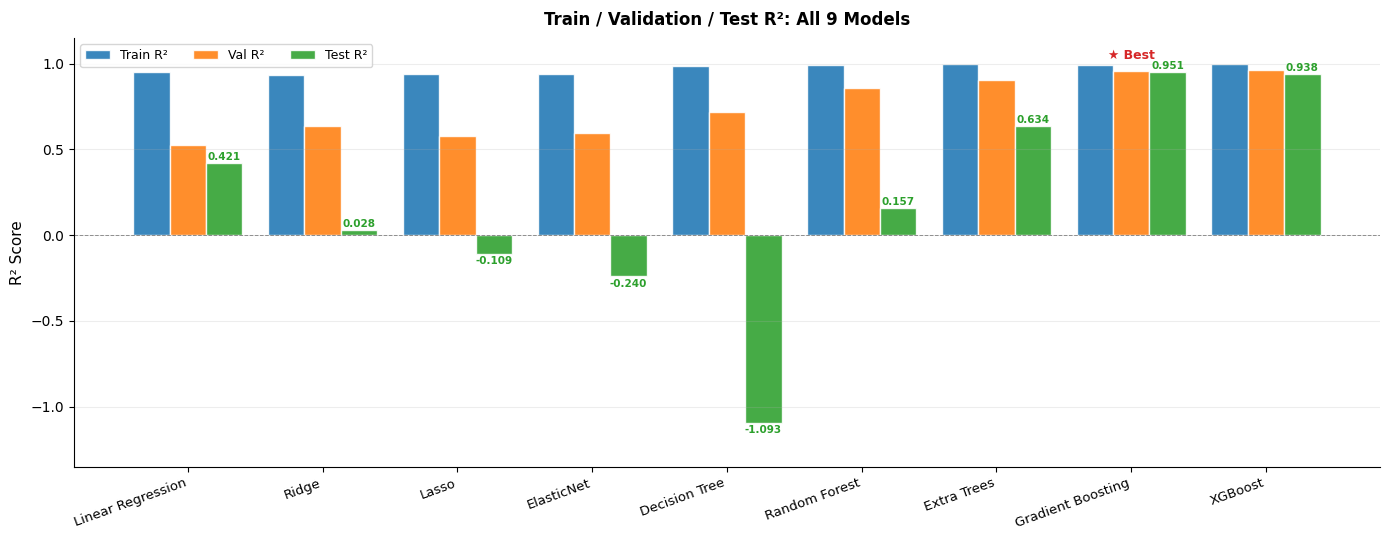

In [17]:
# ── Model comparison bar chart ─────────────────────────────────────────────
model_names  = list(all_results.keys())
train_r2_vals = [all_results[m]['Train_R2'] for m in model_names]
val_r2_vals   = [all_results[m]['Val_R2']   for m in model_names]
test_r2_vals  = [all_results[m]['Test_R2']  for m in model_names]

short_names = [n.split('(')[0].strip() for n in model_names]
x = np.arange(len(model_names)); w = 0.27

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.bar(x - w, train_r2_vals, w, label='Train R²', color='#1f77b4', alpha=0.88, edgecolor='white')
ax.bar(x,     val_r2_vals,   w, label='Val R²',   color='#ff7f0e', alpha=0.88, edgecolor='white')
ax.bar(x + w, test_r2_vals,  w, label='Test R²',  color='#2ca02c', alpha=0.88, edgecolor='white')
ax.axhline(0, color='black', lw=0.7, ls='--', alpha=0.4)

# Annotate Test R² values
for i, (v, bar) in enumerate(zip(test_r2_vals,
                                  ax.patches[2*len(model_names):])):
    ypos = v + 0.02 if v >= 0 else v - 0.06
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{v:.3f}', ha='center', fontsize=7.5,
            color='#2ca02c', fontweight='bold')

# Star best model
best_idx = test_r2_vals.index(max(test_r2_vals))
ax.text(best_idx, max(train_r2_vals) + 0.03, '★ Best',
        ha='center', fontsize=9, color='#d62728', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=20, ha='right', fontsize=9.5)
ax.set_ylabel('R² Score', fontsize=11)
ax.set_ylim(-1.35, 1.15)
ax.set_title('Train / Validation / Test R²: All 9 Models',
             fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=9, ncol=3)
ax.grid(axis='y', alpha=0.22)
plt.tight_layout(); plt.show()

### Figure  
R² Heatmap (All 9 Models)

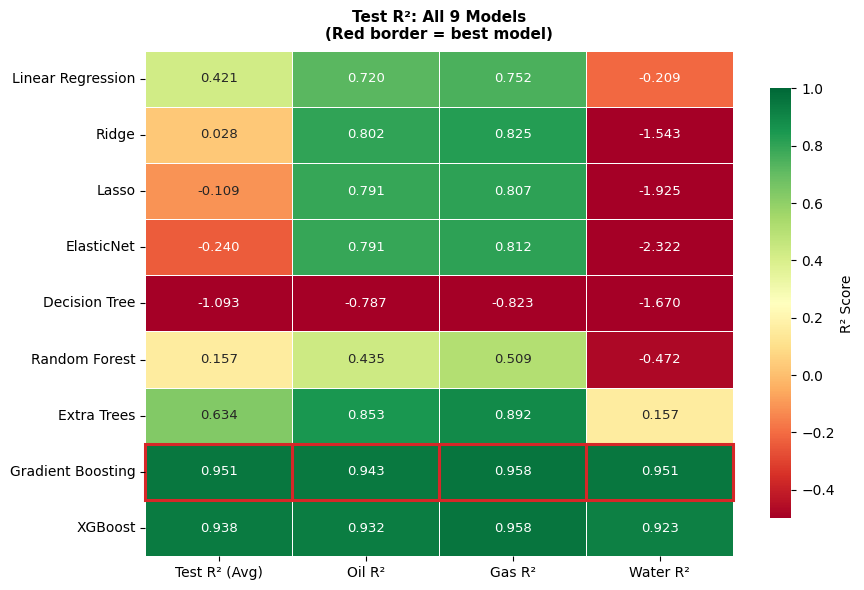

In [18]:
# R² heatmap
import pandas as pd

heatmap_data = pd.DataFrame({
    m: {
        'Test R² (Avg)': all_results[m]['Test_R2'],
        'Oil R²':        all_results[m]['Oil_R2'],
        'Gas R²':        all_results[m]['Gas_R2'],
        'Water R²':      all_results[m]['Wat_R2'],
    }
    for m in model_names
}).T
heatmap_data.index = short_names

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=-0.5, vmax=1.0, linewidths=0.5,
            annot_kws={'size': 9.5}, ax=ax,
            cbar_kws={'label': 'R² Score', 'shrink': 0.85})

# Highlight best model row
best_row_idx = short_names.index(best_name.split('(')[0].strip())
for j in range(len(heatmap_data.columns)):
    ax.add_patch(plt.Rectangle((j, best_row_idx), 1, 1,
                               fill=False, edgecolor='#d62728',
                               lw=2.2, clip_on=False))

ax.set_title('Test R²: All 9 Models\n(Red border = best model)',
             fontsize=11, fontweight='bold', pad=8)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout(); plt.show()

### Actual vs Predicted — Best Model (Test Set)
Scatter plot and residual distribution for the final selected model.

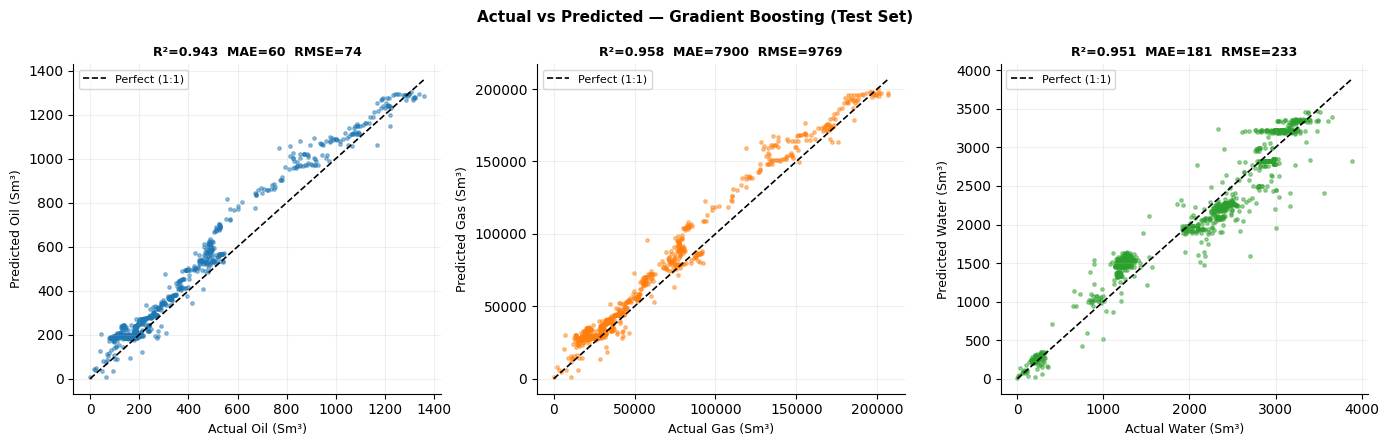

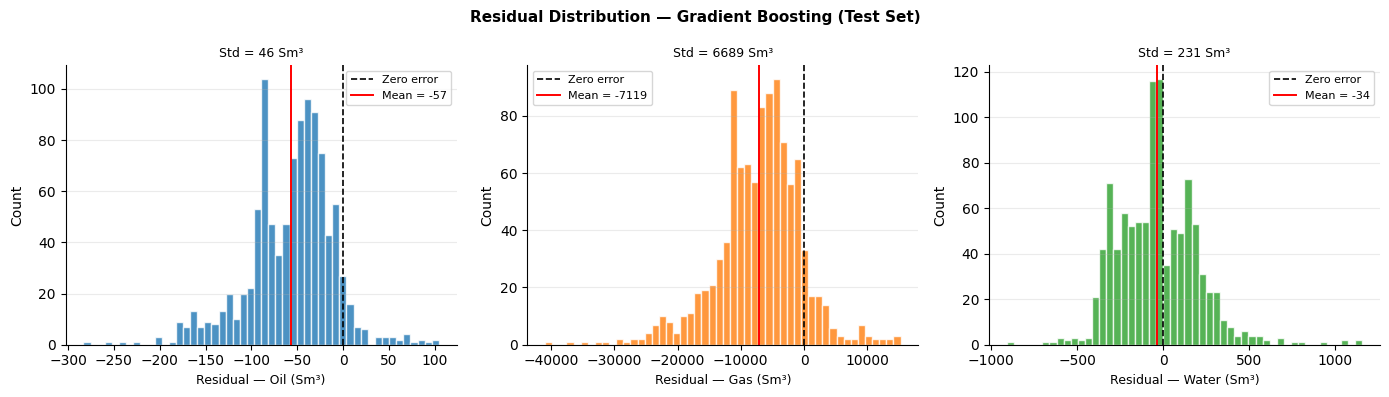

In [19]:
# Actual vs Predicted
best_pred  = all_results[best_name]['pred']
phase_labs = ['Oil (Sm³)', 'Gas (Sm³)', 'Water (Sm³)']
cols       = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for i, (ax, lab, c) in enumerate(zip(axes, phase_labs, cols)):
    ax.scatter(y_test_raw[:, i], best_pred[:, i], s=6, alpha=0.45, color=c)
    mn = min(y_test_raw[:, i].min(), best_pred[:, i].min())
    mx = max(y_test_raw[:, i].max(), best_pred[:, i].max())
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.2, label='Perfect (1:1)')
    r2_i  = r2_score(y_test_raw[:, i], best_pred[:, i])
    mae_i = mean_absolute_error(y_test_raw[:, i], best_pred[:, i])
    rmse_i= float(np.sqrt(mean_squared_error(y_test_raw[:, i], best_pred[:, i])))
    ax.set_xlabel(f'Actual {lab}', fontsize=9)
    ax.set_ylabel(f'Predicted {lab}', fontsize=9)
    ax.set_title(f'R²={r2_i:.3f}  MAE={mae_i:.0f}  RMSE={rmse_i:.0f}',
                 fontsize=9, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.2)
fig.suptitle(f'Actual vs Predicted — {best_name.split("(")[0].strip()} (Test Set)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Residual Distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (ax, lab, c) in enumerate(zip(axes, ['Oil','Gas','Water'], cols)):
    res = y_test_raw[:, i] - best_pred[:, i]
    ax.hist(res, bins=50, color=c, alpha=0.8, edgecolor='white', lw=0.3)
    ax.axvline(0, color='black', lw=1.2, ls='--', label='Zero error')
    ax.axvline(res.mean(), color='red', lw=1.4,
               label=f'Mean = {res.mean():.0f}')
    ax.set_xlabel(f'Residual — {lab} (Sm³)', fontsize=9)
    ax.set_ylabel('Count')
    ax.set_title(f'Std = {res.std():.0f} Sm³', fontsize=9)
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.25)
fig.suptitle(f'Residual Distribution — {best_name.split("(")[0].strip()} (Test Set)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

### Time-Series Prediction — Test Period

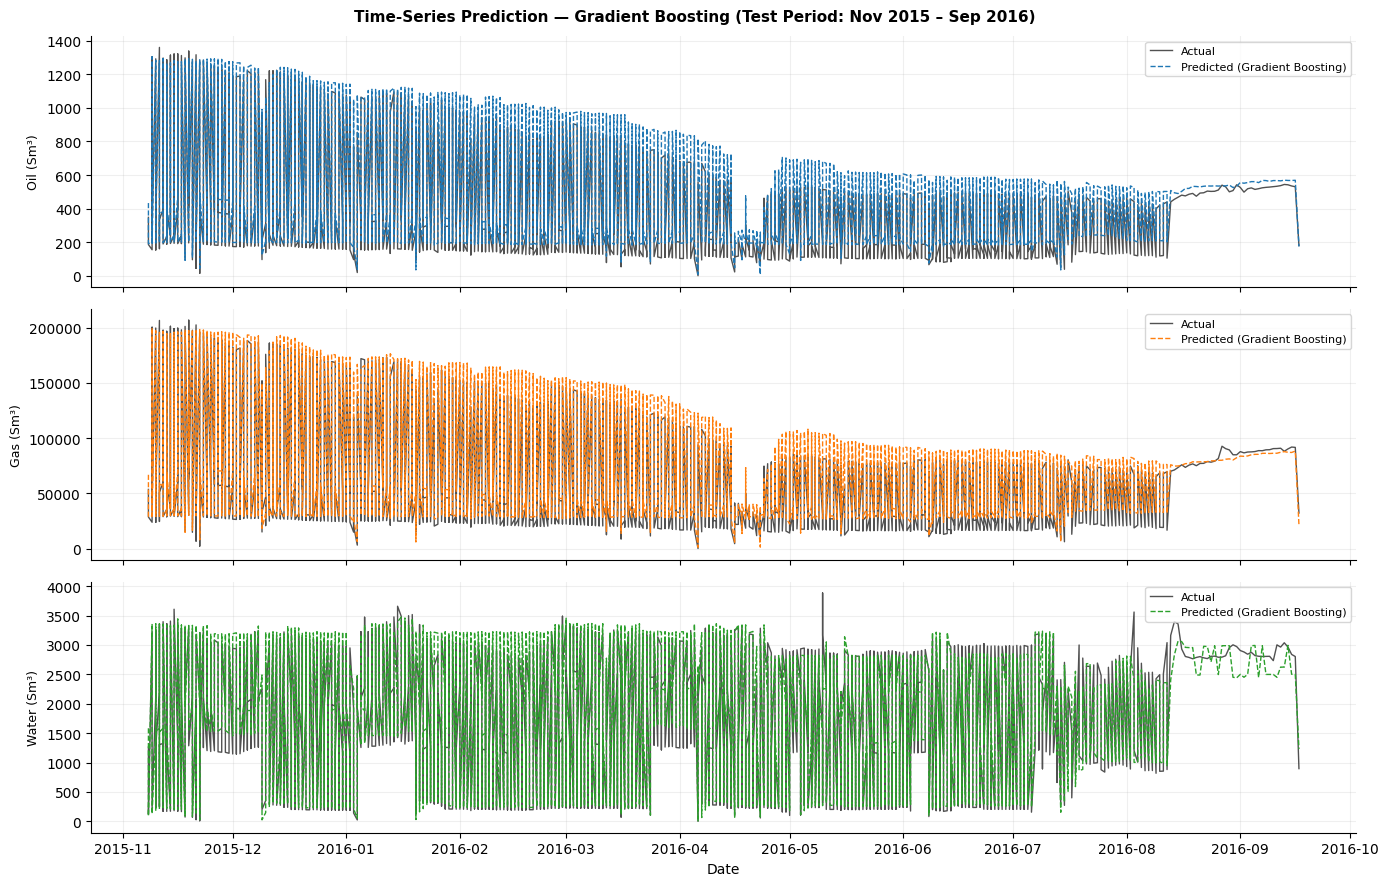

In [20]:
# Time-series prediction vs actuals
test_dates = test['DATEPRD'].values

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for i, (ax, lab, c) in enumerate(zip(axes, phase_labs, cols)):
    ax.plot(test_dates, y_test_raw[:, i], color='#333',
            lw=1.0, label='Actual', alpha=0.85)
    ax.plot(test_dates, best_pred[:, i], color=c,
            lw=1.0, ls='--',
            label=f'Predicted ({best_name.split("(")[0].strip()})')
    ax.set_ylabel(lab, fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.2)
axes[2].set_xlabel('Date')
fig.suptitle(f'Time-Series Prediction — {best_name.split("(")[0].strip()} '
             f'(Test Period: Nov 2015 – Sep 2016)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

## 7. Saving Gradient Boosting, which is the Best Model for Streamlit Deployment


In [21]:
import joblib
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ─────────────────────────────────────────────────────────────────────────
# Saving Trained Objects for Streamlit Deployment
# Following the pattern: 1. Fit & Predict  2. Evaluate  3. Save
# Objects saved: final GB model, MinMaxScaler, feature list
# ─────────────────────────────────────────────────────────────────────────

# 1. Refit the best model (Gradient Boosting) on the full training set
#    using the exact hyperparameters confirmed during evaluation
gb_deploy = MultiOutputRegressor(GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
))
gb_deploy.fit(X_train_s, y_train)
preds = np.expm1(gb_deploy.predict(X_test_s))  # back-transform log → Sm³

# 2. Evaluate performance (R², MAE, RMSE) in original Sm³ space
r2   = r2_score(y_test_raw, preds, multioutput='uniform_average')
mae  = mean_absolute_error(y_test_raw, preds, multioutput='uniform_average')
rmse = float(np.sqrt(mean_squared_error(y_test_raw, preds,
                                         multioutput='uniform_average')))
per_r2 = [r2_score(y_test_raw[:, i], preds[:, i]) for i in range(3)]

print("Gradient Boosting — Deployment Model Performance")
print("-" * 50)
print(f"R²   (avg)  : {r2:.4f}")
print(f"  Oil R²    : {per_r2[0]:.4f}")
print(f"  Gas R²    : {per_r2[1]:.4f}")
print(f"  Water R²  : {per_r2[2]:.4f}")
print(f"MAE         : {mae:,.1f} Sm³/day")
print(f"RMSE        : {rmse:,.1f} Sm³/day")

# 3. Save all objects needed for Streamlit deployment

# 3a. Save the trained Gradient Boosting model
joblib.dump(gb_deploy, 'gradient_boosting_model.pkl')
print("\nModel saved to       : gradient_boosting_model.pkl")

# 3b. Save the MinMaxScaler (must use same scaler fitted on training data)
#     Streamlit app must scale new inputs with this scaler before predicting
joblib.dump(scaler, 'minmax_scaler.pkl')
print("Scaler saved to      : minmax_scaler.pkl")

# 3c. Save the feature list so Streamlit knows column order and names
joblib.dump(FEATURES_ALL, 'features_list.pkl')
print("Feature list saved to: features_list.pkl")

# 3d. Save WELL_COLS so Streamlit can reconstruct the one-hot encoding
joblib.dump(WELL_COLS, 'well_columns.pkl')
print("Well columns saved to: well_columns.pkl")

print("\nAll deployment objects saved successfully.")
print("Load in Streamlit with:")
print("  model    = joblib.load('gradient_boosting_model.pkl')")
print("  scaler   = joblib.load('minmax_scaler.pkl')")
print("  features = joblib.load('features_list.pkl')")
print("  wells    = joblib.load('well_columns.pkl')")


Gradient Boosting — Deployment Model Performance
--------------------------------------------------
R²   (avg)  : 0.9506
  Oil R²    : 0.9427
  Gas R²    : 0.9582
  Water R²  : 0.9509
MAE         : 2,713.8 Sm³/day
RMSE        : 5,641.7 Sm³/day

Model saved to       : gradient_boosting_model.pkl
Scaler saved to      : minmax_scaler.pkl
Feature list saved to: features_list.pkl
Well columns saved to: well_columns.pkl

All deployment objects saved successfully.
Load in Streamlit with:
  model    = joblib.load('gradient_boosting_model.pkl')
  scaler   = joblib.load('minmax_scaler.pkl')
  features = joblib.load('features_list.pkl')
  wells    = joblib.load('well_columns.pkl')
